# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [101]:
import os
import shutil

import scanpy as sc
import anndata as ad
import numpy as np
from sklearn.preprocessing import normalize

from matplotlib.pyplot import rcParams
import matplotlib.pyplot as plt

In [3]:
import warnings
# warnings.filterwarnings(action='once')
warnings.filterwarnings('ignore')

In [4]:
import os
import shutil
import pickle

import scanpy as sc
import pandas as pd
import numpy as np
from pathlib import Path

from scib_metrics.benchmark import Benchmarker

import drvi
from drvi.utils.metrics import DiscreteDisentanglementBenchmark
from drvi_notebooks.utils.data.data_configs import get_data_info
from drvi_notebooks.utils.run_info import get_run_info_for_dataset
from drvi_notebooks.utils.method_info import pretify_method_name
from drvi_notebooks.utils.plotting import plot_per_latent_scatter

In [5]:
# Simple hack
import IPython.display
from matplotlib_inline.backend_inline import set_matplotlib_formats
IPython.display.set_matplotlib_formats = set_matplotlib_formats
    
sc.set_figure_params(vector_friendly=True, dpi_save=300)

In [6]:
import mplscience
mplscience.available_styles()
mplscience.set_style()

['default', 'despine']


# Config

In [7]:
cwd = os.getcwd()

In [8]:
logs_dir = Path(os.path.expanduser('~/workspace/train_logs'))
logs_dir

PosixPath('/home/icb/amirali.moinfar/workspace/train_logs')

In [9]:
proj_dir = Path(cwd).parent.parent
proj_dir

PosixPath('/lustre/groups/ml01/code/amirali.moinfar/projects/drvi_reproducibility_public')

In [60]:
output_dir = proj_dir / 'plots' / 'foi_soi_rank'
output_dir.mkdir(parents=True, exist_ok=True)
output_dir

PosixPath('/lustre/groups/ml01/code/amirali.moinfar/projects/drvi_reproducibility_public/plots/foi_soi_rank')

In [13]:
run_name = 'immune_hvg'
run_version = '4.3'
run_path = os.path.expanduser('~/workspace/train_logs/models')

data_info = get_data_info(run_name, run_version)
wandb_address = data_info['wandb_address']
col_mapping = data_info['col_mapping']
plot_columns = data_info['plot_columns']
pp_function = data_info['pp_function']
data_path = data_info['data_path']
var_gene_groups = data_info['var_gene_groups']
cell_type_key = data_info['cell_type_key']
exp_plot_pp = data_info['exp_plot_pp']
control_treatment_key = data_info['control_treatment_key']
condition_key = data_info['condition_key']
split_key = data_info['split_key']

In [11]:
cat_10_pallete = sc.plotting.palettes.vega_10_scanpy
cat_10_pallete_without_grey = [c for c in cat_10_pallete if c != '#7f7f7f']
cat_20_pallete = sc.plotting.palettes.vega_20_scanpy
wong_pallete = [
    "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#000000",
]
cat_100_pallete = sc.plotting.palettes.godsnot_102

## Utils

In [12]:
original_params = plt.rcParams.copy()
def set_font_in_rc_params():
    fs = 16
    plt.rcParams.update({
        'font.size': fs,            # General font size
        'axes.titlesize': fs,       # Title font size
        'axes.labelsize': fs,       # Axis label font size
        'legend.fontsize': fs,      # Legend font size
        'xtick.labelsize': fs,      # X-axis tick label font size
        'ytick.labelsize': fs       # Y-axis tick label font size
    })

## Data

In [14]:
adata = sc.read(data_path)
adata

AnnData object with n_obs × n_vars = 32484 × 2000
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue'
    var: 'gene_de_sig', 'mean', 'std'
    uns: 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'lognorm'
    obsp: 'connectivities', 'distances'

In [15]:
adata_full = sc.read(Path('~/data/misc/Immune_ALL_human.h5ad').expanduser())
adata_full

AnnData object with n_obs × n_vars = 33506 × 12303
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue'
    layers: 'counts'

# Select model

In [88]:
CURRENT_RUN_DIR = Path("/home/icb/amirali.moinfar/workspace/train_logs/models/drvi_20240430-115959-272081")  # n_latent = 32
# CURRENT_RUN_DIR = Path("/home/icb/amirali.moinfar/workspace/train_logs/models/drvi_20240725-200726-230923")  # n_latent = 64
# CURRENT_RUN_DIR = Path("/home/icb/amirali.moinfar/workspace/train_logs/models/drvi_20240725-204758-332681")  # n_latent = 128  # H100 GPU memory is not enough

In [89]:
embed = sc.read_h5ad(CURRENT_RUN_DIR / "latent.h5ad")
model = drvi.model.DRVI.load(CURRENT_RUN_DIR / 'model.pt', adata, prefix='v_0_1_0_')
adata.obsm['X_umap_drvi'] = embed[adata.obs.index].obsm['X_umap']

INFO     File                                                                                                      
         /home/icb/amirali.moinfar/workspace/train_logs/models/drvi_20240430-115959-272081/model.pt/v_0_1_0_model.p
         t already downloaded                                                                                      
INFO     DRVI: The model has been initialized                                                                      


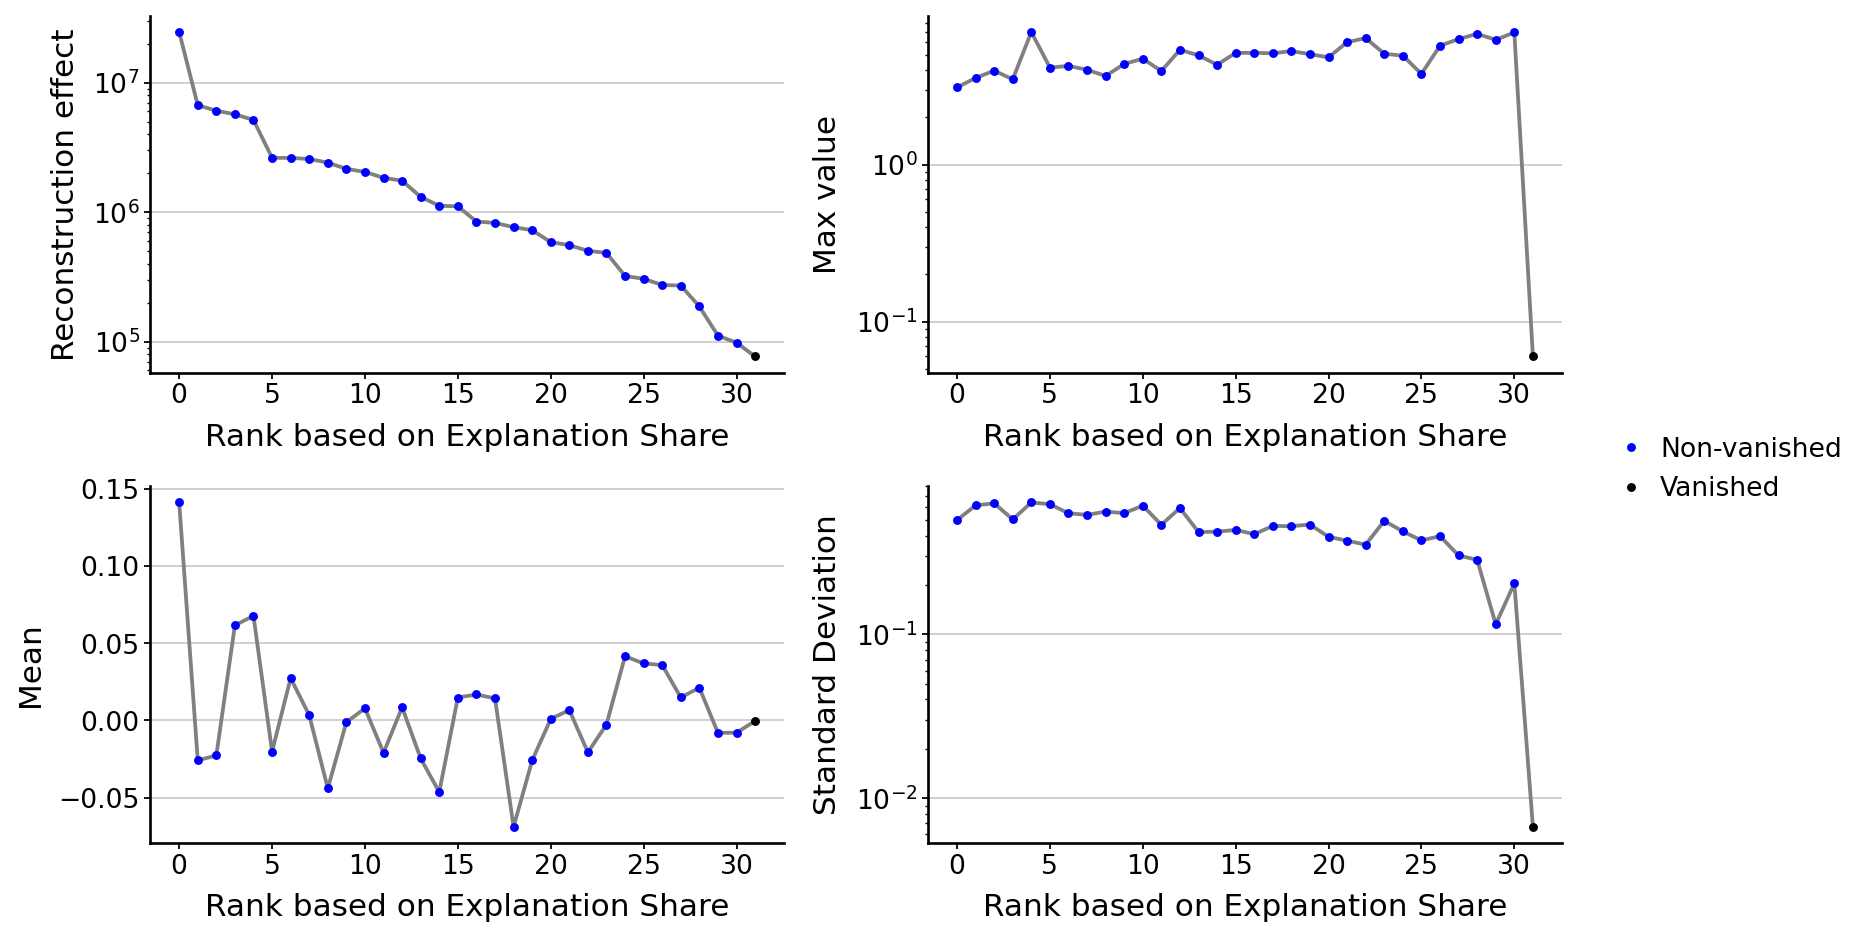

In [90]:
drvi.utils.tl.set_latent_dimension_stats(model, embed)
drvi.utils.pl.plot_latent_dimension_stats(embed, ncols=2)

In [91]:
filename = CURRENT_RUN_DIR / "traverse_adata.h5ad"
if not (filename).exists():
    traverse_adata = drvi.utils.tl.traverse_latent(model, embed, n_samples=200, max_noise_std=0.2)
    drvi.utils.tl.calculate_differential_vars(traverse_adata)
    traverse_adata.write(filename)
else:
    traverse_adata = sc.read(filename)
traverse_adata

AnnData object with n_obs × n_vars = 128000 × 2000
    obs: 'original_order', 'dim_id', 'sample_id', 'step_id', 'span_value', 'lib_size', 'title', 'vanished', 'order'
    var: 'gene_de_sig', 'mean', 'std', 'original_order'
    uns: 'combined_score_traverse_effect_neg_dim_ids', 'combined_score_traverse_effect_pos_dim_ids', 'combined_score_traverse_effect_stepwise', 'max_possible_traverse_effect_neg_dim_ids', 'max_possible_traverse_effect_pos_dim_ids', 'max_possible_traverse_effect_stepwise', 'min_possible_traverse_effect_neg_dim_ids', 'min_possible_traverse_effect_pos_dim_ids', 'min_possible_traverse_effect_stepwise'
    obsm: 'cat_covs', 'control_latent', 'effect_latent'
    varm: 'combined_score_traverse_effect_neg', 'combined_score_traverse_effect_pos', 'max_possible_traverse_effect_neg', 'max_possible_traverse_effect_pos', 'min_possible_traverse_effect_neg', 'min_possible_traverse_effect_pos'
    layers: 'control', 'effect'

In [92]:
gene_correspondance = {g: ('None', 0) for g in adata.var.index}
for dim_title, scores in drvi.utils.tl.iterate_on_top_differential_vars(traverse_adata, key="combined_score", score_threshold=0.1):
    for g, score in scores.items():
        if score > gene_correspondance[g][1]:
            gene_correspondance[g] = (dim_title, score)

gene_correspondance = {g: v[0] for g, v in gene_correspondance.items()}

In [93]:
adata.var['gene_dr_sig'] = adata.var.index.map(gene_correspondance)
adata.var

,gene_de_sig,mean,std,gene_dr_sig
index,,,,
IGLL5,CD10+ B cells / CD20+ B cells,0.029942,0.258568,DR 13+
TCL1A,CD10+ B cells,0.110601,0.438412,DR 17-
PTGDS,Plasmacytoid dendritic cells,0.031105,0.236423,DR 17-
CD79A,NaN,0.213072,0.586373,DR 13+
PPBP,Erythrocytes / Erythroid progenitors / Megakar...,0.062012,0.302913,DR 5-
...,...,...,...,...
IL16,CD4+ T cells / CD8+ T cells / NKT cells,0.225218,0.417960,DR 1+
ZNF605,NaN,0.022648,0.135801,DR 1+
TNFSF4,NaN,0.003033,0.045673,DR 5-


# FOI | SOI matrix calculation

## Select a subset of indices

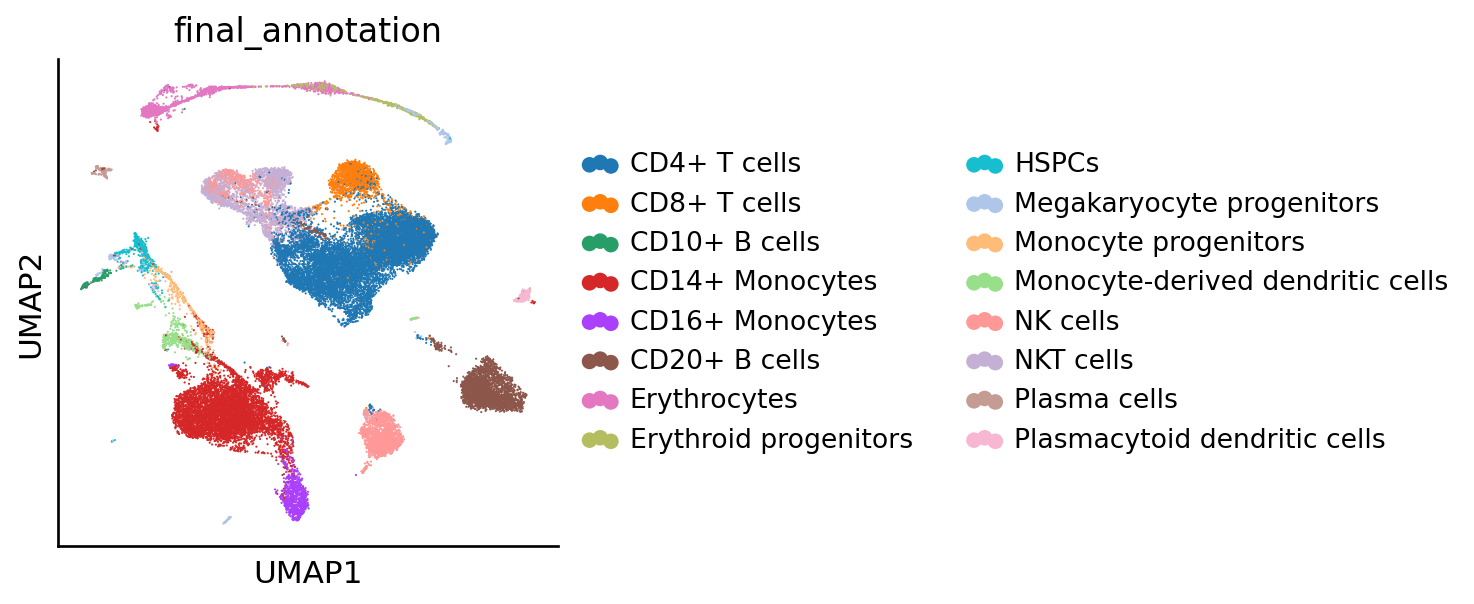

In [94]:
sc.pl.umap(embed, color=[cell_type_key])

In [95]:
# In distribution sampling

# # multiple samples per ct and batch
# n_sample_per_group = 2
# subset_indices = []
# for grp, obs_subset in adata.obs.groupby([condition_key, cell_type_key]):
#     subset_indices += list(obs_subset.sample(n=min(len(obs_subset), n_sample_per_group)).index)
# subset_indices = np.where(adata.obs.index.isin(subset_indices))[0]
# subset_indices.shape

subset_indices = np.arange(embed.n_obs)
latent = embed[subset_indices].X
cat_values = adata[subset_indices].obs[condition_key].values

In [96]:
# Out of distribution sampling

# latent = np.random.uniform(embed.var['min'].values, embed.var['max'].values, size=latent.shape).astype(np.float32)

## Calculation of FOI, SOI

In [97]:
foi_32 = model.compute_derivatives(latent, cat_values=cat_values, map_cat_values=True, derivative_type="first_order")
foi_32.shape

(32484, 2000, 32)

In [98]:
soi_32 = model.compute_derivatives(latent, cat_values=cat_values, map_cat_values=True, derivative_type="second_order")
soi_32.shape

(32484, 2000, 32)

In [99]:
import gc
import torch
gc.collect(2)
torch.cuda.empty_cache()

In [100]:
# Remove vanished dimensions
keep_dims = (embed.var['vanished'] == False)
suff_ind_matrix = np.stack([foi_32, soi_32], axis=-1)[:, :, keep_dims, :]

suff_ind_matrix = suff_ind_matrix.reshape(suff_ind_matrix.shape[0], suff_ind_matrix.shape[1], suff_ind_matrix.shape[2] * 2)
col_info = pd.concat([embed.var[keep_dims].assign(kind='foi'), embed.var[keep_dims].assign(kind='soi')], axis=0)
col_info = col_info.iloc[sum([[i, i + len(col_info) // 2] for i in range(len(col_info) // 2)], [])].reset_index(drop=True)
print(suff_ind_matrix.shape)

(32484, 2000, 62)


In [102]:
eigen_values_list = []
ranks = []
for i in range(suff_ind_matrix.shape[0]):
    mat = suff_ind_matrix[i]
    mat = normalize(mat, norm="l2", axis=0)
    eigen_values = np.linalg.svd(mat, compute_uv=False)
    eigen_values_list.append(eigen_values)
    # print("eigen_values:", eigen_values)
    # separate_eigen_values = np.concatenate([np.linalg.svd(mat[:, j:j+1], compute_uv=False) for j in range(mat.shape[1])])
    # print(eigen_values.sum(), separate_eigen_values.sum())
    
    rank = (eigen_values > 0).sum()
    # print("Rank:", rank)
    ranks.append(rank)


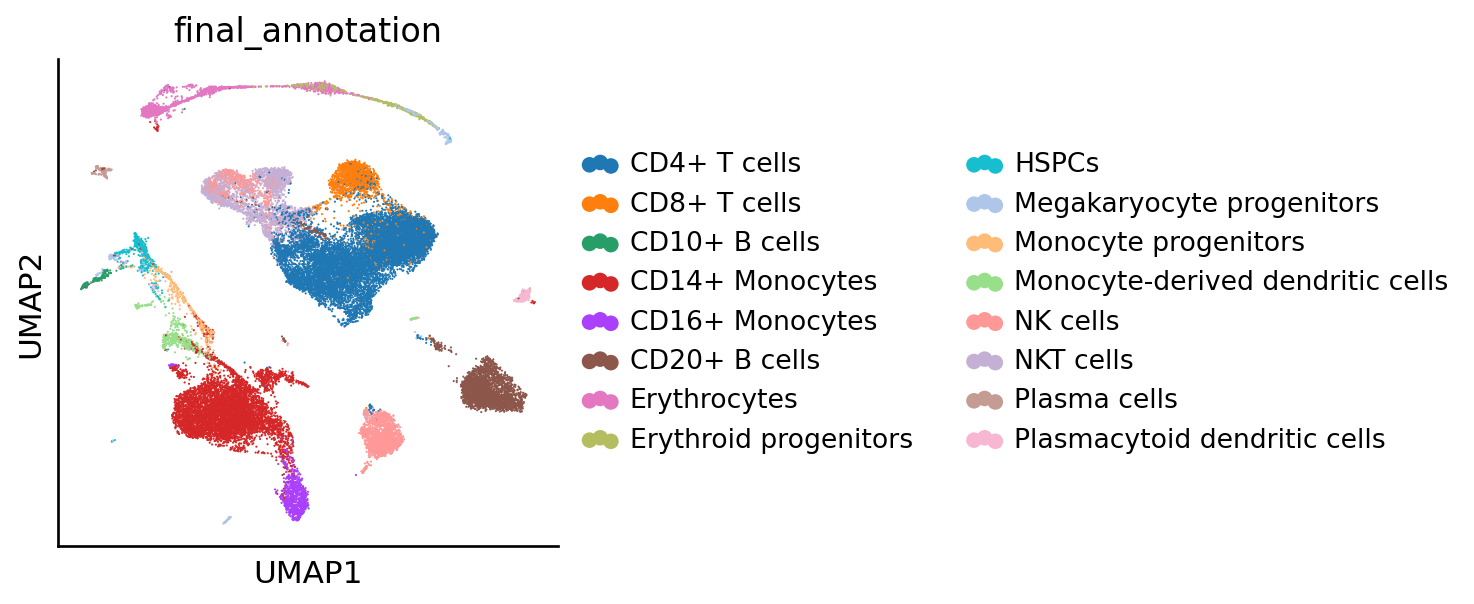

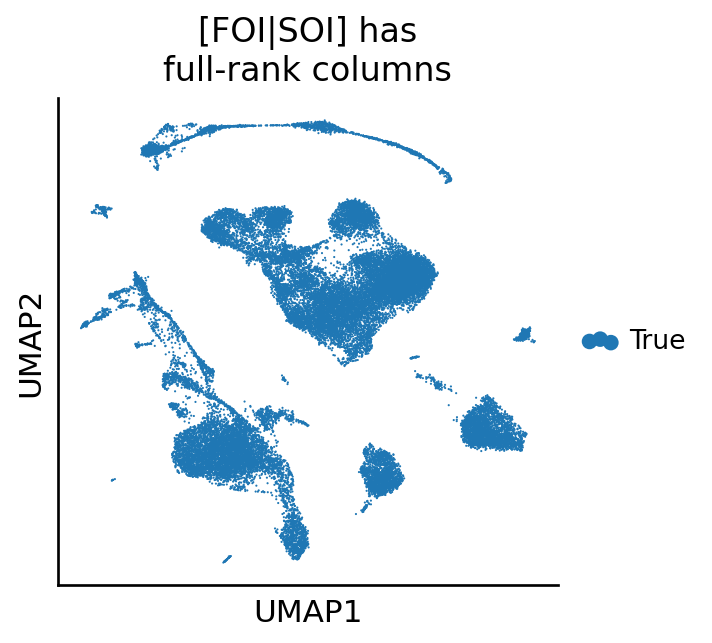

In [103]:
embed.obs['suff_ind_full_rank'] = (np.array(ranks) == 2 * (embed.var['vanished'] == False).sum()).astype(str)
sc.pl.umap(embed, color=[cell_type_key], ncols=1)
sc.pl.umap(embed, color=['suff_ind_full_rank'], ncols=1, title='[FOI|SOI] has\nfull-rank columns')

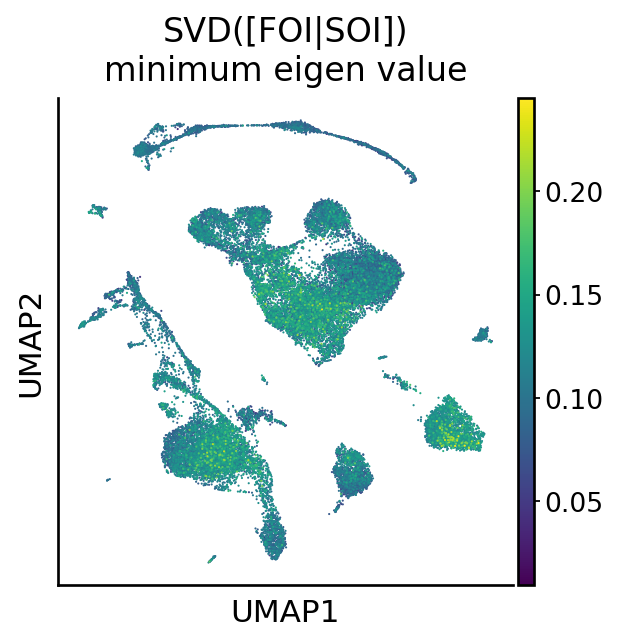

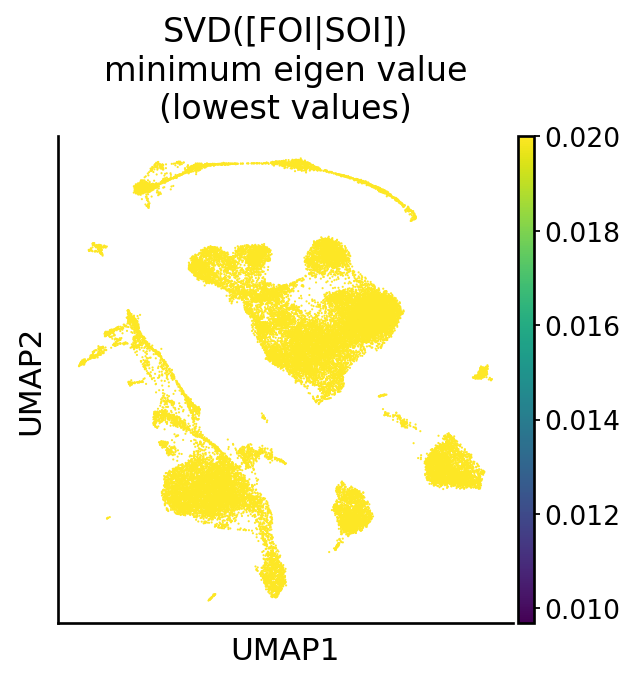

In [105]:
embed.obs['suff_ind_svd_min_eigen_value'] = np.stack(eigen_values_list).min(axis=1)
sc.pl.umap(embed, color=['suff_ind_svd_min_eigen_value'], ncols=1, title='SVD([FOI|SOI])\nminimum eigen value')
sc.pl.umap(embed, color=['suff_ind_svd_min_eigen_value'], ncols=1, vmax=0.02, title='SVD([FOI|SOI])\nminimum eigen value\n(lowest values)')

# Select model

In [107]:
# CURRENT_RUN_DIR = Path("/home/icb/amirali.moinfar/workspace/train_logs/models/drvi_20240430-115959-272081")  # n_latent = 32
CURRENT_RUN_DIR = Path("/home/icb/amirali.moinfar/workspace/train_logs/models/drvi_20240725-200726-230923")  # n_latent = 64
# CURRENT_RUN_DIR = Path("/home/icb/amirali.moinfar/workspace/train_logs/models/drvi_20240725-204758-332681")  # n_latent = 128  # H100 GPU memory is not enough

In [108]:
embed = sc.read_h5ad(CURRENT_RUN_DIR / "latent.h5ad")
model = drvi.model.DRVI.load(CURRENT_RUN_DIR / 'model.pt', adata, prefix='v_0_1_0_')
adata.obsm['X_umap_drvi'] = embed[adata.obs.index].obsm['X_umap']

INFO     File                                                                                                      
         /home/icb/amirali.moinfar/workspace/train_logs/models/drvi_20240725-200726-230923/model.pt/v_0_1_0_model.p
         t already downloaded                                                                                      
INFO     DRVI: The model has been initialized                                                                      


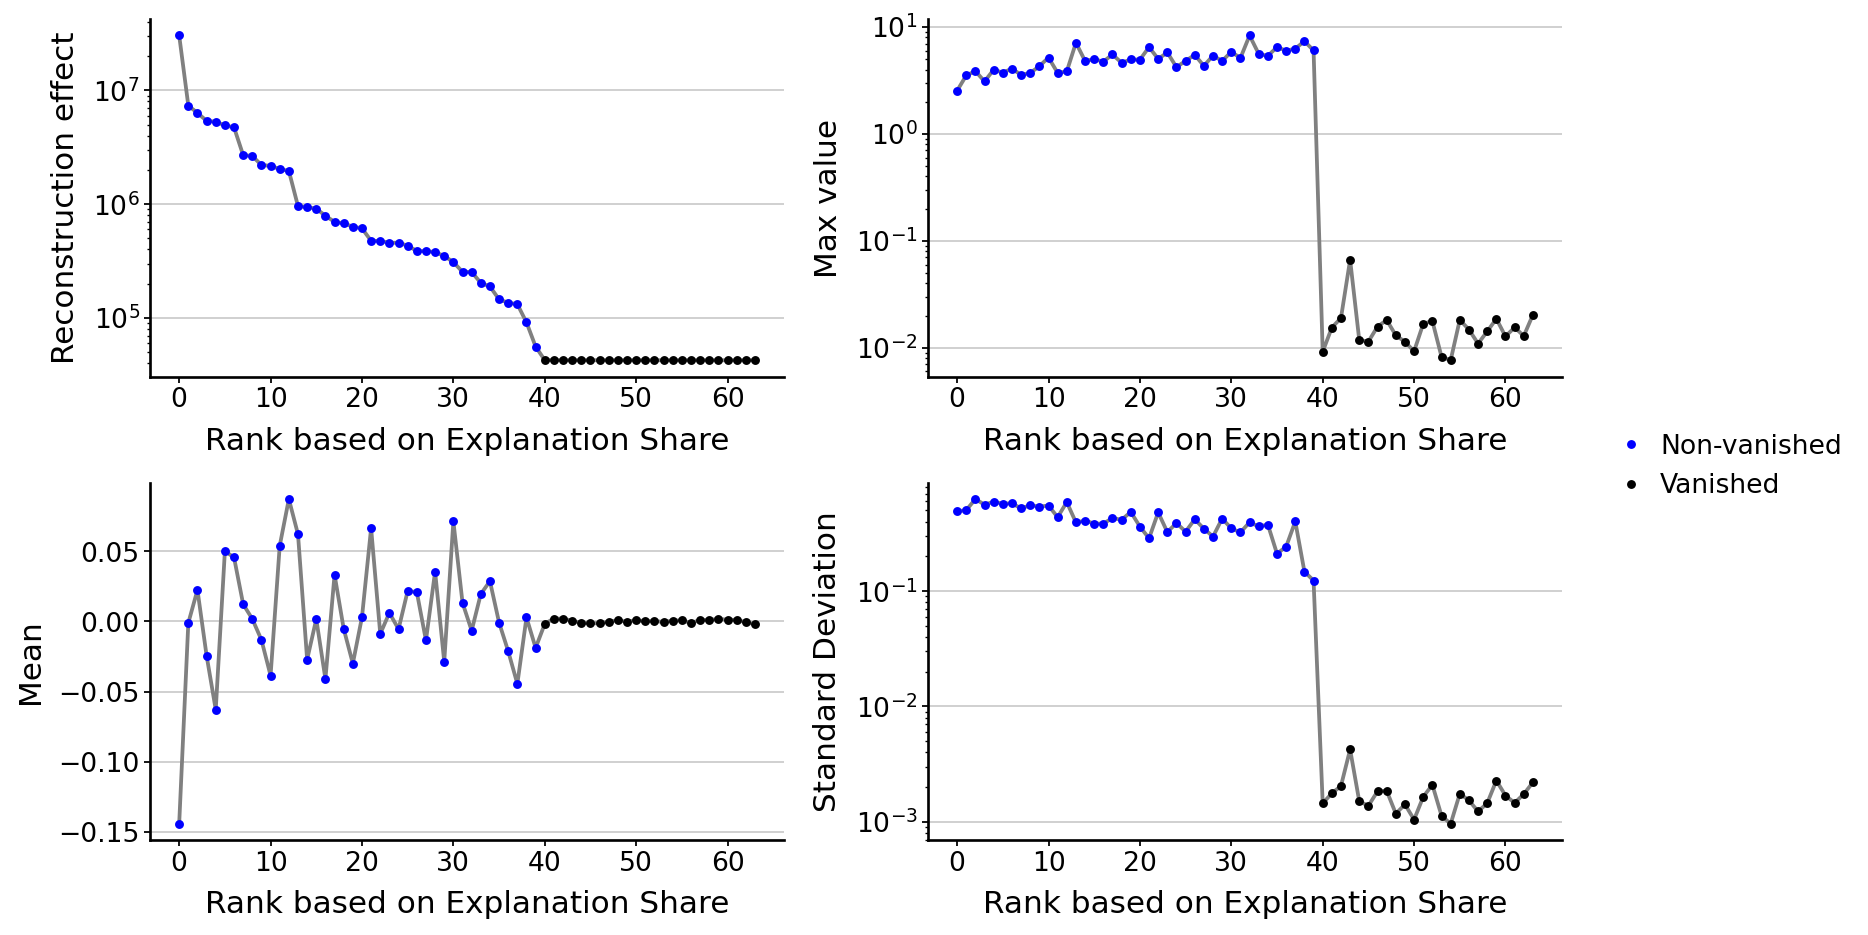

In [109]:
drvi.utils.tl.set_latent_dimension_stats(model, embed)
drvi.utils.pl.plot_latent_dimension_stats(embed, ncols=2)

# FOI | SOI matrix calculation

## Select a subset of indices

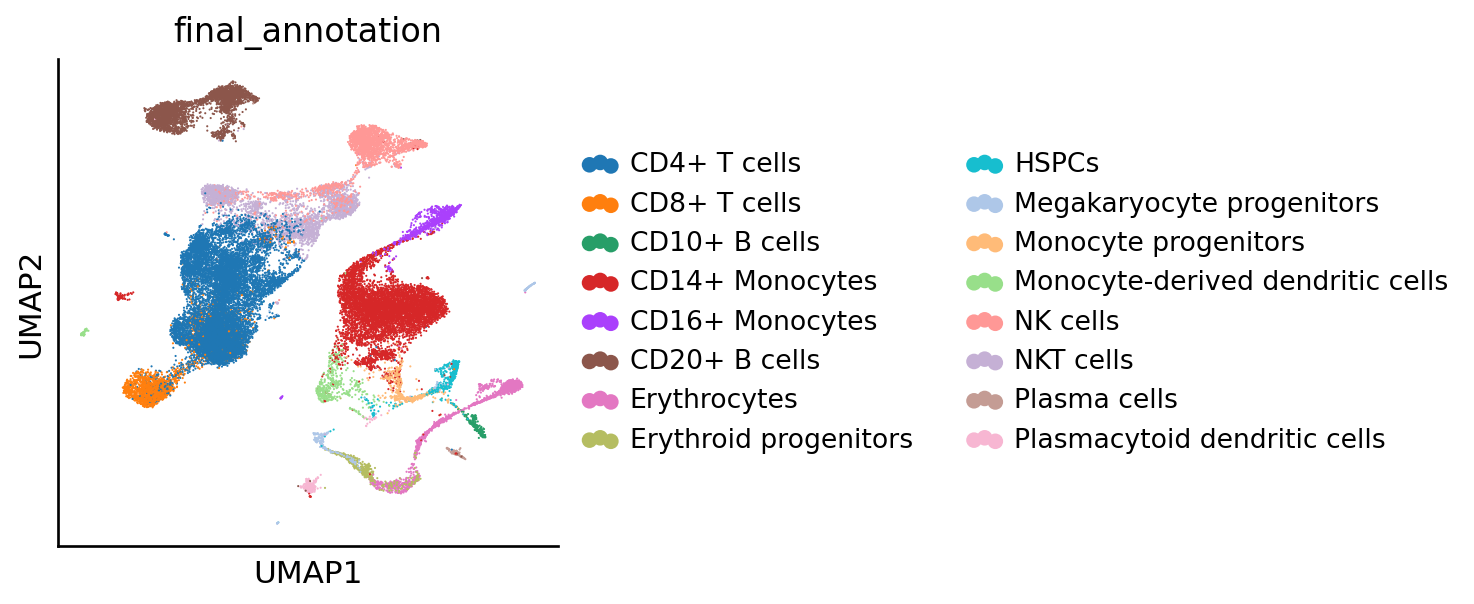

In [110]:
sc.pl.umap(embed, color=[cell_type_key])

In [111]:
# In distribution sampling

# # multiple samples per ct and batch
# n_sample_per_group = 2
# subset_indices = []
# for grp, obs_subset in adata.obs.groupby([condition_key, cell_type_key]):
#     subset_indices += list(obs_subset.sample(n=min(len(obs_subset), n_sample_per_group)).index)
# subset_indices = np.where(adata.obs.index.isin(subset_indices))[0]
# subset_indices.shape

subset_indices = np.arange(embed.n_obs)
latent = embed[subset_indices].X
cat_values = adata[subset_indices].obs[condition_key].values

In [112]:
# Out of distribution sampling

# latent = np.random.uniform(embed.var['min'].values, embed.var['max'].values, size=latent.shape).astype(np.float32)

## Calculation of FOI, SOI

In [86]:
foi_64 = model.compute_derivatives(latent, cat_values=cat_values, map_cat_values=True, derivative_type="first_order")
foi_64.shape

(32484, 2000, 64)

In [87]:
soi_64 = model.compute_derivatives(latent, cat_values=cat_values, map_cat_values=True, derivative_type="second_order")
soi_64.shape

(32484, 2000, 64)

In [113]:
import gc
import torch
gc.collect(2)
torch.cuda.empty_cache()

In [114]:
# Remove vanished dimensions
keep_dims = (embed.var['vanished'] == False)
suff_ind_matrix = np.stack([foi_64, soi_64], axis=-1)[:, :, keep_dims, :]

suff_ind_matrix = suff_ind_matrix.reshape(suff_ind_matrix.shape[0], suff_ind_matrix.shape[1], suff_ind_matrix.shape[2] * 2)
col_info = pd.concat([embed.var[keep_dims].assign(kind='foi'), embed.var[keep_dims].assign(kind='soi')], axis=0)
col_info = col_info.iloc[sum([[i, i + len(col_info) // 2] for i in range(len(col_info) // 2)], [])].reset_index(drop=True)
print(suff_ind_matrix.shape)

(32484, 2000, 80)


In [115]:
eigen_values_list = []
ranks = []
for i in range(suff_ind_matrix.shape[0]):
    mat = suff_ind_matrix[i]
    mat = normalize(mat, norm="l2", axis=0)
    eigen_values = np.linalg.svd(mat, compute_uv=False)
    eigen_values_list.append(eigen_values)
    # print("eigen_values:", eigen_values)
    # separate_eigen_values = np.concatenate([np.linalg.svd(mat[:, j:j+1], compute_uv=False) for j in range(mat.shape[1])])
    # print(eigen_values.sum(), separate_eigen_values.sum())
    
    rank = (eigen_values > 0).sum()
    # print("Rank:", rank)
    ranks.append(rank)


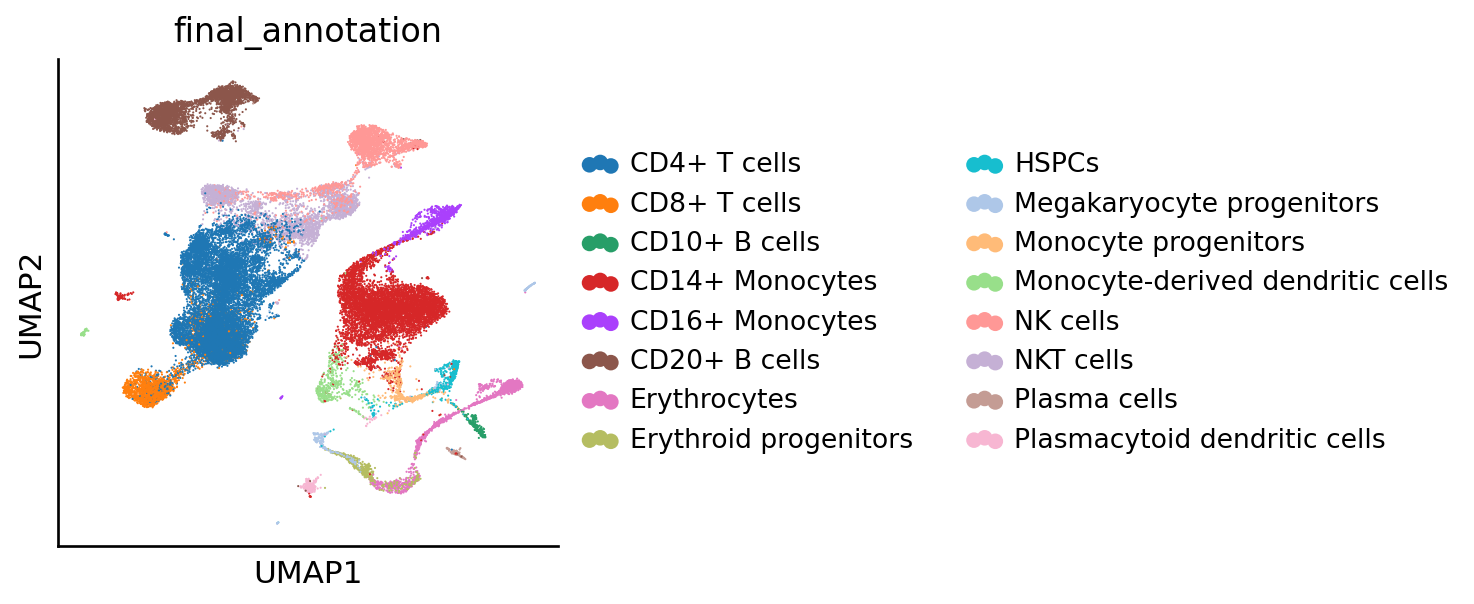

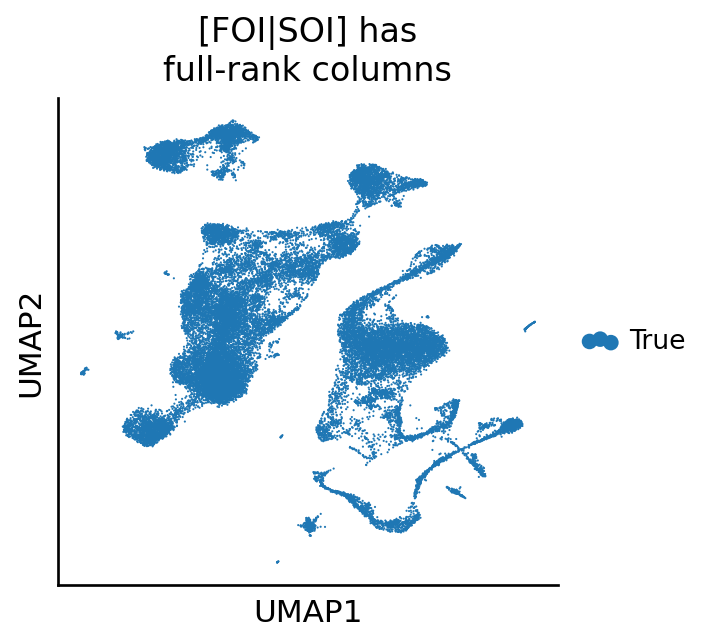

In [116]:
embed.obs['suff_ind_full_rank'] = (np.array(ranks) == 2 * (embed.var['vanished'] == False).sum()).astype(str)
sc.pl.umap(embed, color=[cell_type_key], ncols=1)
sc.pl.umap(embed, color=['suff_ind_full_rank'], ncols=1, title='[FOI|SOI] has\nfull-rank columns')

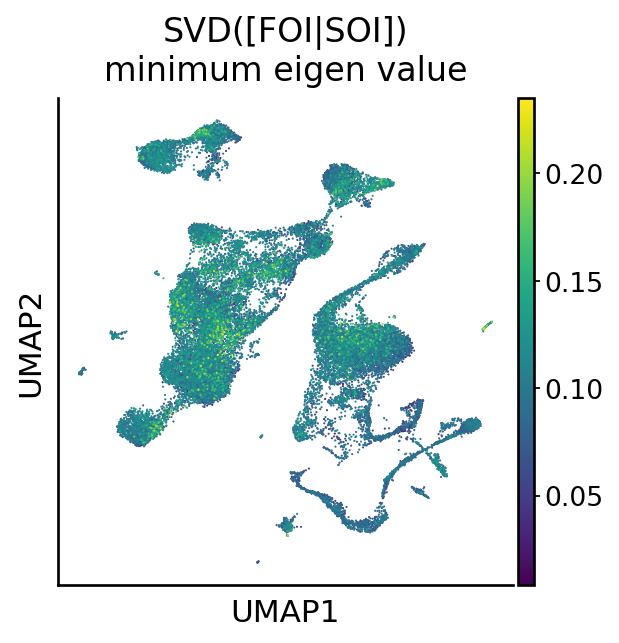

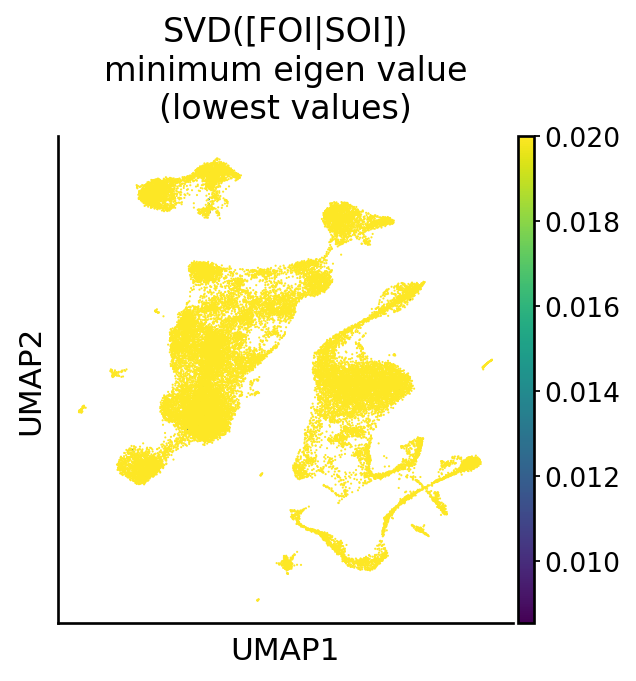

In [118]:
embed.obs['suff_ind_svd_min_eigen_value'] = np.stack(eigen_values_list).min(axis=1)
sc.pl.umap(embed, color=['suff_ind_svd_min_eigen_value'], ncols=1, title='SVD([FOI|SOI])\nminimum eigen value')
sc.pl.umap(embed, color=['suff_ind_svd_min_eigen_value'], ncols=1, vmax=0.02, title='SVD([FOI|SOI])\nminimum eigen value\n(lowest values)')